# 极值条件与凸性

学习目标：区分驻点、局部与全局极值及鞍点，按条件使用梯度和 Hessian 判据；判断凸性，观察梯度更新的步长行为，并选学约束下的拉格朗日几何。

前置知识：函数定义域、梯度、方向导数、二阶导数与 Hessian、二阶局部近似、内积、正定与半正定矩阵；Python 函数与数组操作。

运行环境：Python 3.12，NumPy、Matplotlib；所有例子均为自制的无量纲实函数，使用小型数组。

环境准备：见 [数学基础环境与运行说明](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 附近最好，不等于处处最好

先看定义在 $\mathbb R$ 上的函数 $f(t)=t^3-3t$，其中 $t$ 是实数。令输入在 $t=1$ 附近变化，写成 $1+h$，$h$ 是变化量。直接展开得到

$$f(1+h)=-2+h^2(3+h).$$

当 $0<|h|<1$ 时，后一项为正，所以 $t=1$ 比附近其他点的函数值都小。但 $f(-3)=-18<-2$，它并不是整个定义域上最小的点。

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def cubic(t):
    return t**3 - 3 * t


nearby = np.array([0.9, 1.0, 1.1])
print("附近输入与函数值：", nearby, cubic(nearby))  # 预期约为 [0.9 1. 1.1] [-1.971 -2. -1.969]。
print("较远点的函数值：", cubic(-3.0))  # 预期为 -18。
# 局部判断来自上面的展开式；三个采样点本身不足以证明局部最小。

附近输入与函数值： [0.9 1.  1.1] [-1.971 -2.    -1.969]
较远点的函数值： -18.0


一般地，设 $f:D\to\mathbb R$，其中 $D\subseteq\mathbb R^n$，$n$ 是正整数。点 $x_*\in D$ 是局部极小点，指存在半径 $\delta>0$，对满足 $x\in D$、$\|x-x_*\|_2<\delta$ 的点都有 $f(x_*)\leq f(x)$。若这个不等式对所有 $x\in D$ 都成立，则是全局极小点。

把不等号反向就得到极大点；除 $x=x_*$ 外都取严格不等号时，称为严格局部极值。点 $x_*$ 与数值 $f(x_*)$ 分别是极值点和极值。

当前三次函数在 $t=-1$ 有严格局部极大值 $2$，因为 $f(-1+h)=2+h^2(h-3)$。它同样不是全局极大值。

In [2]:
near_maximum = np.array([-1.1, -1.0, -0.9])
print("局部极大点附近：", cubic(near_maximum))  # 预期约为 [1.969 2. 1.971]。
print("更大的远处函数值：", cubic(3.0))  # 预期为 18。
# f(t) 在 t 趋于正、负无穷时分别趋于正、负无穷，因此没有全局极大或极小值。

局部极大点附近： [1.969 2.    1.971]
更大的远处函数值： 18.0


## 2 一阶条件只筛选候选点

对可微函数，满足 $\nabla f(x_*)=0$ 的点称为驻点（stationary point）。本章把梯度写成 $n\times1$ 列向量，代码用长度为 $n$ 的一维数组承载；@ 表示内积或矩阵乘法。

若 $x_*$ 是定义域内点，且 $f$ 在该点可微，那么局部极值必须满足梯度为零。理由是：对任意方向 $v\in\mathbb R^n$，单变量函数 $\phi(s)=f(x_*+sv)$ 在 $s=0$ 处也有局部极值，所以 $\phi'(0)=\nabla f(x_*)^Tv=0$。对所有方向都成立，只能有 $\nabla f(x_*)=0$。

这个必要条件不是充分条件。例如 $t^3$ 在零点导数为零，却在任意小邻域内同时有正值和负值。边界点也不能直接套用：$f(t)=t$ 在 $[0,\infty)$ 上的最小点是 $0$，但它的导数为 $1$。

In [3]:
small_inputs = np.array([-0.01, 0.0, 0.01])
print("t³ 在零点附近的值：", small_inputs**3)  # 预期为 [-1.e-06 0.e+00 1.e-06]。
print("t³ 在零点的导数：", 3 * 0.0**2)  # 预期为 0。
print("边界例子 f(t)=t 的可行输入和值：", np.array([0.0, 0.01, 1.0]))  # 预期约为 [0. 0.01 1. ]。
# 第一组说明驻点未必是极值；第二组的最小点处于可行域边界。

t³ 在零点附近的值： [-1.e-06  0.e+00  1.e-06]
t³ 在零点的导数： 0.0
边界例子 f(t)=t 的可行输入和值： [0.   0.01 1.  ]


## 3 二阶条件怎样区分驻点

下面假设 $f$ 在内点 $x_*$ 的某个邻域内二阶连续可微。Hessian 矩阵记为 $H_f(x)=[\partial^2 f/\partial x_i\partial x_j]\in\mathbb R^{n\times n}$，其中 $i,j=1,\ldots,n$；该条件下它是对称矩阵。

在驻点处，一阶项消失，二阶展开为

$$
f(x_*+h)-f(x_*)=\tfrac12h^TH_f(x_*)h+R(h),\qquad
\frac{R(h)}{\|h\|_2^2}\longrightarrow0,
$$

其中 $h\in\mathbb R^n$ 是趋近零的非零变化量，$R(h)$ 是余项。二次型的符号决定主要变化方向。

局部极小点的 Hessian 必须半正定；否则可沿负曲率方向找到更小值。局部极大点必须半负定。反方向的充分判据如下，均以“已经是驻点”为前提。

| Hessian 条件 | 含义 | 可得结论 |
| --- | --- | --- |
| Positive definite | 正定，所有特征值为正 | 严格局部极小点 |
| Negative definite | 负定，所有特征值为负 | 严格局部极大点 |
| Indefinite | 不定，同时存在正、负特征值 | 鞍点 |

这里鞍点指梯度为零，但任意小邻域都有比该点更高和更低的函数值。正定二次型在所有非零方向上都为正，且足以压过上述更高阶余项；这说明充分条件为什么还需要邻域内的光滑性。

In [4]:
hessians = {
    "极小：x²+y²": np.array([[2.0, 0.0], [0.0, 2.0]]),
    "极大：-x²-y²": np.array([[-2.0, 0.0], [0.0, -2.0]]),
    "鞍点：x²-y²": np.array([[2.0, 0.0], [0.0, -2.0]]),
}
for name, hessian in hessians.items():
    print(name, "Hessian 特征值：", np.linalg.eigvalsh(hessian))  # 极小、极大、鞍点的特征值依次为 [2, 2]、[-2, -2]、[-2, 2]。
# 三个函数在原点的梯度都为零；eigvalsh 用于实对称矩阵的特征值。

极小：x²+y² Hessian 特征值： [2. 2.]
极大：-x²-y² Hessian 特征值： [-2. -2.]
鞍点：x²-y² Hessian 特征值： [-2.  2.]


三幅等高线图分别画出 $x^2+y^2$、$-x^2-y^2$ 与 $x^2-y^2$。横纵轴是两个无量纲输入，颜色表示函数值；三个原点都以黑点标记。鞍点沿不同方向呈现相反变化，不能只沿一条线检查。

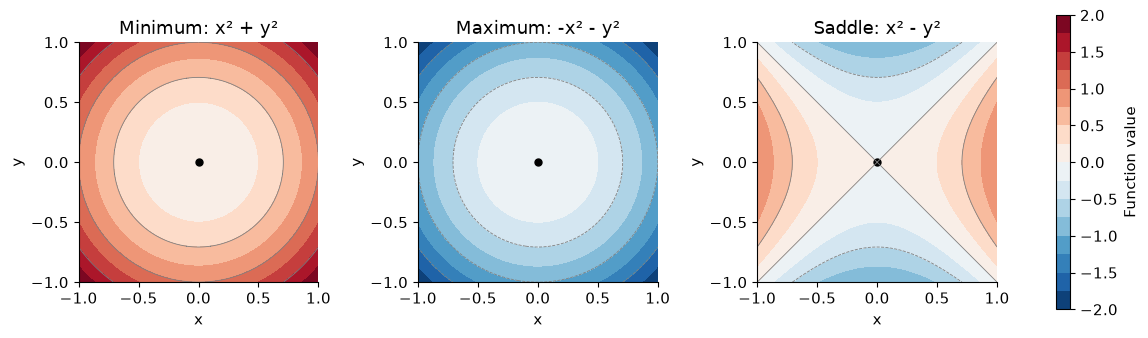

In [5]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)
blue, orange, green = "#0072B2", "#D55E00", "#009E73"
# 三个函数共用网格与颜色层级，黑点都标在驻点 (0, 0)。
coordinates = np.linspace(-1.0, 1.0, 121)
X, Y = np.meshgrid(coordinates, coordinates)
surfaces = [X**2 + Y**2, -(X**2) - Y**2, X**2 - Y**2]
titles = ["Minimum: x² + y²", "Maximum: -x² - y²", "Saddle: x² - y²"]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.7), layout="constrained")
# 填色展示函数值，细等高线帮助观察沿不同方向上升或下降。
for ax, surface, title in zip(axes, surfaces, titles):
    filled = ax.contourf(X, Y, surface, levels=np.linspace(-2, 2, 17), cmap="RdBu_r")
    ax.contour(
        X,
        Y,
        surface,
        levels=[-1.5, -1, -0.5, 0, 0.5, 1, 1.5],
        colors="0.5",
        linewidths=0.6,
    )
    ax.scatter([0], [0], color="black", s=25)
    ax.set(xlabel="x", ylabel="y", title=title)
    ax.set_aspect("equal")
fig.colorbar(filled, ax=axes, label="Function value", shrink=0.82)
# 预期左图从中心向外升高、中图向外降低；右图沿两个坐标方向一升一降。
plt.show()

## 4 退化的二阶信息可能不够

Hessian 半正定不代表该点一定极小。若它半正定但非正定，或半负定但非负定，零曲率方向可能由更高阶项决定。即使是严格极小点，Hessian 也可能有零特征值。

例如 $x^4+y^4$、$-x^4-y^4$、$x^4-y^4$ 在原点的梯度与 Hessian 全为零，却分别是严格极小、严格极大和鞍点。前两个函数可直接由四次方非负判断；第三个在两条坐标轴上符号相反。

“退化”指 Hessian 不可逆，不能机械等同于“任何判据都失效”：高维矩阵即使有零特征值，只要同时有正、负特征值，仍能用不定性判断鞍点。

In [6]:
epsilon = 0.1
probes = np.array([[epsilon, 0.0], [0.0, epsilon]])
for px, py in probes:
    # 两个轴向探测点的前两值均为 +1e-4、-1e-4；第三个函数分别为 +1e-4、-1e-4。
    print(
        "探测点：",
        (px, py),
        "三个函数值：",
        (px**4 + py**4, -(px**4) - py**4, px**4 - py**4),
    )
print("共同的原点 Hessian：", np.zeros((2, 2)))  # 预期为 [[0. 0.] [0. 0.]]。
# 固定探测点只是展示；对任意足够小的非零 epsilon，以上符号结论仍成立。

探测点： (np.float64(0.1), np.float64(0.0)) 三个函数值： (np.float64(0.00010000000000000002), np.float64(-0.00010000000000000002), np.float64(0.00010000000000000002))
探测点： (np.float64(0.0), np.float64(0.1)) 三个函数值： (np.float64(0.00010000000000000002), np.float64(-0.00010000000000000002), np.float64(-0.00010000000000000002))
共同的原点 Hessian： [[0. 0.]
 [0. 0.]]


## 5 凸集要求整条线段留在集合内

集合 $C\subseteq\mathbb R^n$ 是凸集（convex set），指任意 $a,b\in C$ 和任意 $\theta\in[0,1]$ 都满足

$$\theta a+(1-\theta)b\in C.$$

$\theta$ 是线段上的混合权重。闭单位圆盘 $\{x:\|x\|_2\leq1\}$ 是凸集，因为三角不等式给出 $\|\theta a+(1-\theta)b\|_2\leq\theta\|a\|_2+(1-\theta)\|b\|_2\leq1$。

只有边界的单位圆周 $\{x:\|x\|_2=1\}$ 则不是凸集：$(1,0)^T$ 和 $(-1,0)^T$ 都在圆周上，中点却在圆心。

In [7]:
point_a = np.array([1.0, 0.0])
point_b = np.array([-1.0, 0.0])
for weight in [0.0, 0.25, 0.5, 0.75, 1.0]:
    mixed = weight * point_a + (1 - weight) * point_b
    length = np.linalg.norm(mixed)
    # 所有点都在圆盘内；只有 θ=0、1 两端仍在圆周上，中点长度为 0。
    print(
        f"θ={weight:.2f}，长度={length:.2f}，在圆盘内={length <= 1.0}，在圆周上={np.isclose(length, 1.0)}"
    )
# 这条线段就能反驳圆周凸性；证明圆盘凸性仍需前面的任意点推导。

θ=0.00，长度=1.00，在圆盘内=True，在圆周上=True
θ=0.25，长度=0.50，在圆盘内=True，在圆周上=False
θ=0.50，长度=0.00，在圆盘内=True，在圆周上=False
θ=0.75，长度=0.50，在圆盘内=True，在圆周上=False
θ=1.00，长度=1.00，在圆盘内=True，在圆周上=True


## 6 凸函数与弦线

在凸定义域 $C$ 上，函数 $f:C\to\mathbb R$ 是凸函数（convex function），指对所有 $a,b\in C$、$\theta\in[0,1]$，

$$f(\theta a+(1-\theta)b)\leq\theta f(a)+(1-\theta)f(b).$$

右侧是两个函数值的线性插值。在一维图中，函数曲线位于任意两点的连线下方或线上。若 $a\ne b$ 且 $0<\theta<1$ 时总取严格不等号，就称为严格凸；$-f$ 凸时，$f$ 称为凹函数。

以 $f(t)=t^2$ 为例，直接展开弦线与函数值之差：

$$\theta a^2+(1-\theta)b^2-[\theta a+(1-\theta)b]^2
=\theta(1-\theta)(a-b)^2\geq0.$$

这同时证明了它的严格凸性。定义本身不要求导数存在。

In [8]:
endpoint_a, endpoint_b = -1.0, 2.0
for weight in [0.0, 0.25, 0.5, 0.75, 1.0]:
    mixed = weight * endpoint_a + (1 - weight) * endpoint_b
    chord_value = weight * endpoint_a**2 + (1 - weight) * endpoint_b**2
    gap = chord_value - mixed**2
    formula_gap = weight * (1 - weight) * (endpoint_a - endpoint_b) ** 2
    print(f"θ={weight:.2f}，弦线减函数值={gap:.6f}，展开式={formula_gap:.6f}")  # 两列相等，依次为 0、1.6875、2.25、1.6875、0，均非负。
# 端点处差为零；两个不同端点之间的差为正。

θ=0.00，弦线减函数值=0.000000，展开式=0.000000
θ=0.25，弦线减函数值=1.687500，展开式=1.687500
θ=0.50，弦线减函数值=2.250000，展开式=2.250000
θ=0.75，弦线减函数值=1.687500，展开式=1.687500
θ=1.00，弦线减函数值=0.000000，展开式=0.000000


下图选择端点 $-1$ 与 $2$，连接它们的函数值。蓝线是 $t^2$，橙色虚线是弦线。单幅图只展示一对端点，凸性的证明来自上面对任意端点的恒等式。

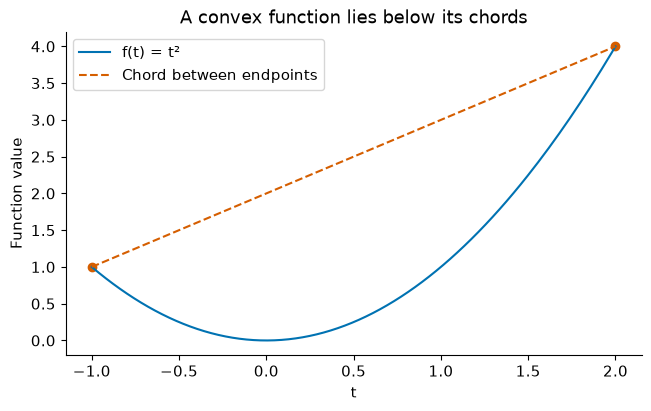

In [9]:
line_inputs = np.linspace(endpoint_a, endpoint_b, 150)
# 按区间位置计算两个端点的权重，再对端点函数值做线性插值得到弦线。
chord_weights = (endpoint_b - line_inputs) / (endpoint_b - endpoint_a)
chord_values = chord_weights * endpoint_a**2 + (1 - chord_weights) * endpoint_b**2
fig, ax = plt.subplots(figsize=(6.4, 4), layout="constrained")
ax.plot(line_inputs, line_inputs**2, color=blue, label="f(t) = t²")
ax.plot(line_inputs, chord_values, "--", color=orange, label="Chord between endpoints")
ax.scatter([endpoint_a, endpoint_b], [endpoint_a**2, endpoint_b**2], color=orange)
ax.set(
    xlabel="t", ylabel="Function value", title="A convex function lies below its chords"
)
ax.legend()
# 预期两端点处曲线与弦线相交，中间的抛物线位于弦线下方。
plt.show()

## 7 一阶与二阶凸性条件

下面先限定定义域 $D\subseteq\mathbb R^n$ 是开凸集。若 $f$ 可微，则它凸当且仅当对所有 $a,b\in D$ 有

$$f(b)\geq f(a)+\nabla f(a)^T(b-a).$$

也就是说，每一点的一阶近似都给出整个定义域上的下界。对 $f(x)=x^Tx$，梯度为 $2x$，两边的差恰好是 $\|b-a\|_2^2$，因此不等式成立。

In [10]:
base_point = np.array([1.0, -1.0])
other_point = np.array([-0.5, 2.0])
actual_value = other_point @ other_point
linear_bound = base_point @ base_point + (2 * base_point) @ (other_point - base_point)

print("函数值与一阶下界：", actual_value, linear_bound)  # 预期约为 4.25 -7。
print("二者的差：", actual_value - linear_bound)  # 预期约为 11.25。
print("两点距离的平方：", np.linalg.norm(other_point - base_point) ** 2)  # 预期约为 11.25。
# 这里的全局下界性质由平方范数恒等式保证，不是仅在邻域内近似。

函数值与一阶下界： 4.25 -7.0
二者的差： 11.25
两点距离的平方： 11.250000000000002


若进一步二阶连续可微，则在这个开凸定义域上，$f$ 凸当且仅当 $H_f(x)$ 对每个 $x\in D$ 都半正定。要求“每一点”，也要求“凸定义域”，不能只检查一个位置或有限网格。

看一维反例 $q(t)=t^4-t^2$：$q''(t)=12t^2-2$ 在 $t=1$ 处为正，在 $t=0$ 处却为负。取 $a=-1/2,b=1/2,\theta=1/2$，中点函数值大于两端平均，直接违反凸定义。

In [11]:
def nonconvex_quartic(t):
    return t**4 - t**2


check_points = np.array([-1.0, 0.0, 1.0])
print("检查位置及二阶导数：", check_points, 12 * check_points**2 - 2)  # 预期为 [-1. 0. 1.] [10. -2. 10.]。
print("中点值：", nonconvex_quartic(0.0))  # 预期为 0。
print("两端函数值的平均：", 0.5 * (nonconvex_quartic(-0.5) + nonconvex_quartic(0.5)))  # 预期约为 -0.1875。
# 一个正的单点二阶导数不能证明整个实数域上的凸性。

检查位置及二阶导数： [-1.  0.  1.] [10. -2. 10.]
中点值： 0.0
两端函数值的平均： -0.1875


凸性把局部极小与全局极小联系起来：凸函数在凸定义域上的任意局部极小点都是全局极小点。若远处有更低的点，把它与局部极小点连线；凸不等式会在线段上给出任意近且更低的点，与局部极小矛盾。

在可微、无约束的凸情形中，梯度为零因而成为全局极小的充分条件：把 $\nabla f(x_*)=0$ 代入一阶下界，就有 $f(b)\geq f(x_*)$。严格凸时，极小点如果存在就唯一；但凸性本身不保证它存在，也不保证唯一。

例如 $f(x,y)=x^2$ 的全局极小点是整条 $x=0$ 直线；仿射函数 $f(t)=t$ 在 $\mathbb R$ 上凸，却没有最小值。

In [12]:
for y in [-2.0, 0.0, 3.0]:
    print("x² 的一个全局极小点：", (0.0, y), "函数值：", 0.0)  # y=-2、0、3 的三个点函数值都为 0。
print("仿射凸函数 t 在越来越小输入处的值：", np.array([-1.0, -10.0, -100.0]))  # 预期为 [ -1. -10. -100.]。
# 多个最优点或没有最优点，都与“凸”这个条件相容。

x² 的一个全局极小点： (0.0, -2.0) 函数值： 0.0
x² 的一个全局极小点： (0.0, 0.0) 函数值： 0.0
x² 的一个全局极小点： (0.0, 3.0) 函数值： 0.0
仿射凸函数 t 在越来越小输入处的值： [  -1.  -10. -100.]


## 8 梯度更新还需要合适步长

梯度下降更新写成 $x_{k+1}=x_k-\alpha\nabla f(x_k)$。这里 $x_k\in\mathbb R^n$ 是第 $k$ 次迭代点，$k=0,1,\ldots$，$\alpha>0$ 是步长。

当梯度非零时，沿负梯度的方向导数是 $-\|\nabla f(x_k)\|_2^2<0$，所以足够小的一步会降低函数值。这个局部结论没有保证任意步长都能下降；在驻点处，这个更新也可能停在极大点或鞍点。

用严格凸二次函数 $f(x,y)=\tfrac12(x^2+8y^2)$ 观察，其梯度为 $(x,8y)^T$，唯一极小点是原点。

In [13]:
def quadratic(point):
    x, y = point
    return 0.5 * (x**2 + 8 * y**2)


def quadratic_gradient(point):
    return np.array([point[0], 8 * point[1]])


start = np.array([1.0, 1.0])
for step_size in [0.1, 0.4]:
    next_point = start - step_size * quadratic_gradient(start)
    print("步长、下一点：", step_size, next_point)  # 步长 0.1 得到 [0.9, 0.2]；步长 0.4 得到 [0.6, -2.2]。
    print("更新前后函数值：", quadratic(start), quadratic(next_point))  # 前者目标值从 4.5 降到 0.565；后者从 4.5 升到 19.54。
# 同一个凸函数，较大的步长也可能让目标值上升。

步长、下一点： 0.1 [0.9 0.2]
更新前后函数值： 4.5 0.565
步长、下一点： 0.4 [ 0.6 -2.2]
更新前后函数值： 4.5 19.540000000000003


本例能直接写出每个坐标的更新：

$$x_{k+1}=(1-\alpha)x_k,\qquad y_{k+1}=(1-8\alpha)y_k.$$

要让任意起点的两个坐标都趋于零，需要 $|1-\alpha|<1$ 且 $|1-8\alpha|<1$，即 $0<\alpha<1/4$。从 $(1,1)^T$ 出发，$\alpha=1/4$ 时第二坐标反复变号而不衰减；$\alpha>1/4$ 时它的幅度增长。

这是对当前二次函数的完整推导，不是一般非线性函数通用的步长范围。下面仅固定迭代次数作观察。

In [14]:
histories = {}
iterations = 25
for step_size in [0.05, 0.2, 0.25, 0.3]:
    point = start.copy()
    values = [quadratic(point)]
    for _ in range(iterations):
        point = point - step_size * quadratic_gradient(point)
        values.append(quadratic(point))
    histories[step_size] = np.array(values)
    expected = np.array(
        [(1 - step_size) ** iterations, (1 - 8 * step_size) ** iterations]
    )
    print(f"α={step_size:.2f}，末点={point}，末次目标值={values[-1]:.6e}")  # α=0.05、0.20 时目标值降小；α=0.25 时约为 4，α=0.30 时增大。
    # 各步长的迭代与逐坐标公式一致，相对尺度误差接近 0。
    print(
        "与逐坐标公式的相对尺度误差：",
        np.linalg.norm(point - expected) / max(1.0, np.linalg.norm(expected)),
    )
# 边界步长不是“更慢地收敛”：它的第二坐标保持 ±1。

α=0.05，末点=[2.77389573e-01 2.84302880e-06]，末次目标值=3.847249e-02
与逐坐标公式的相对尺度误差： 2.7755575615661227e-16
α=0.20，末点=[ 3.77789319e-03 -2.84302880e-06]，末次目标值=7.136271e-06
与逐坐标公式的相对尺度误差： 4.770489634134456e-18
α=0.25，末点=[ 7.52543458e-04 -1.00000000e+00]，末次目标值=4.000000e+00
与逐坐标公式的相对尺度误差： 0.0
α=0.30，末点=[ 1.34106862e-04 -4.49987958e+03]，末次目标值=8.099566e+07
与逐坐标公式的相对尺度误差： 4.0423068461522376e-16


将各步长的迭代轨迹画在一起，比较同一目标函数的值在不同步长下怎样变化。

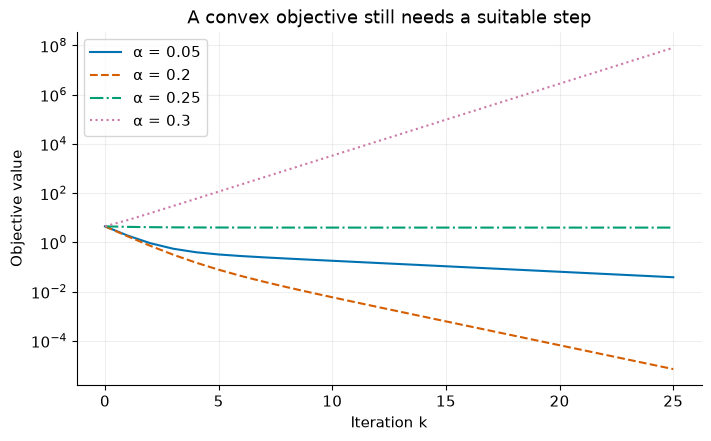

In [15]:
# 横轴为迭代次数，纵轴为函数值；纵轴采用对数刻度，同时观察衰减与增长。
fig, ax = plt.subplots(figsize=(7, 4.3), layout="constrained")
for (step_size, values), color, style in zip(
    histories.items(), [blue, orange, green, "#CC79A7"], ["-", "--", "-.", ":"]
):
    ax.semilogy(
        np.arange(values.size), values, style, color=color, label=f"α = {step_size:g}"
    )
ax.set(
    xlabel="Iteration k",
    ylabel="Objective value",
    title="A convex objective still needs a suitable step",
)
ax.grid(alpha=0.2)
ax.legend()
# 本例固定迭代预算下，步长 0.05 下降较慢，0.2 下降较快；
# 0.25 保留非零误差，0.3 发散。
plt.show()

## 9 选学：约束与拉格朗日几何

加入约束后，只能与可行点比较函数值。考虑两个无量纲变量 $x,y\in\mathbb R$，目标为 $f(x,y)=x+2y$，可行点满足 $g(x,y)=x^2+y^2-1=0$。可行集合是单位圆周；这里目标梯度 $(1,2)^T$ 始终不为零，仍然可能在圆周上取得极值。

单个等式约束的拉格朗日条件是：若 $f,g$ 在候选点附近连续可微、该点是约束局部极值，并且 $\nabla g\ne0$，则存在实数乘子 $\lambda$，使

$$\nabla f=\lambda\nabla g,\qquad g=0.$$

其几何含义是目标在可行切线方向上的变化率为零，目标梯度与约束法向量平行。也可定义拉格朗日函数 $\mathcal L(x,y,\lambda)=f(x,y)-\lambda g(x,y)$，分别对三个变量求偏导并令其为零，得到相同方程。符号选加号时，乘子符号相应改变。

当前例子的方程为 $1=2\lambda x$、$2=2\lambda y$、$x^2+y^2=1$。由前两式得 $y=2x$，代入约束后得到两个候选点：

$$
(x,y)=\pm\frac{(1,2)}{\sqrt5},\qquad
\lambda=\pm\frac{\sqrt5}{2},\qquad f=\pm\sqrt5.
$$

乘子方程本身只给必要条件。这里还能用内积不等式证明 $|x+2y|\leq\sqrt{1^2+2^2}\sqrt{x^2+y^2}=\sqrt5$，因此两个候选点分别达到全局最大、最小值。

In [16]:
objective_normal = np.array([1.0, 2.0])
positive_point = objective_normal / np.sqrt(5.0)
for sign in [-1.0, 1.0]:
    point = sign * positive_point
    multiplier = sign * np.sqrt(5.0) / 2
    constraint_gradient = 2 * point
    tangent = np.array([-point[1], point[0]])
    # 两个候选点约为 ±[0.447214, 0.894427]；目标值分别为 -√5、√5。
    print("候选点、乘子、目标值：", point, multiplier, objective_normal @ point)
    print("约束残差：", point @ point - 1)  # 两次约束残差都接近 0，本次约 -1.1e-16。
    print("梯度平行关系残差：", objective_normal - multiplier * constraint_gradient)  # 两次梯度平行关系残差均为 [0, 0]。
    print("沿可行切线的方向导数：", objective_normal @ tangent)  # 两个候选点的可行切向导数均为 0。
# 输入量级约为 1，以上关系的数值误差应在 1e-12 以下。

候选点、乘子、目标值： [-0.4472136  -0.89442719] -1.118033988749895 -2.23606797749979
约束残差： -1.1102230246251565e-16
梯度平行关系残差： [0. 0.]
沿可行切线的方向导数： 0.0
候选点、乘子、目标值： [0.4472136  0.89442719] 1.118033988749895 2.23606797749979
约束残差： -1.1102230246251565e-16
梯度平行关系残差： [0. 0.]
沿可行切线的方向导数： 0.0


蓝线是可行圆周，虚线是最大值点处的切线，橙色箭头表示目标梯度的方向，并为作图缩短长度。这里 $\nabla g$ 与它平行，具体比例已经用乘子核对；梯度不需要为零。

条件 $\nabla g\ne0$ 不能省略。若约束表示退化，使约束梯度为零，以上必要性定理就不能直接使用。对非凸可行集合，也不能仅凭目标函数凸就套用无约束的驻点结论。

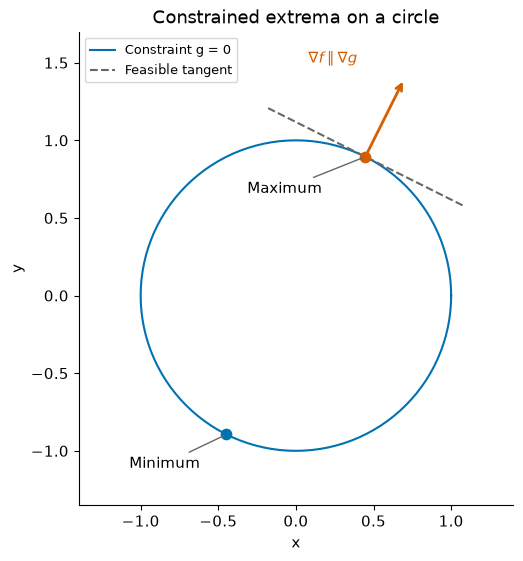

In [17]:
# 用角度参数画约束圆；切向方向垂直于圆在候选点的法向。
angles = np.linspace(0.0, 2 * np.pi, 241)
tangent_direction = np.array([-positive_point[1], positive_point[0]])
# 两行分别是切线的两个端点，由候选点沿切向正负移动得到。
tangent_ends = positive_point + np.array([-0.7, 0.7])[:, None] * tangent_direction
fig, ax = plt.subplots(figsize=(5.8, 5.5), layout="constrained")
ax.plot(np.cos(angles), np.sin(angles), color=blue, label="Constraint g = 0")
ax.plot(
    tangent_ends[:, 0], tangent_ends[:, 1], "--", color="0.4", label="Feasible tangent"
)
ax.scatter(*positive_point, color=orange, s=55, zorder=3)
ax.scatter(*(-positive_point), color=blue, s=55, zorder=3)
# 目标梯度箭头从最大值候选点出发，长度缩放仅用于清楚展示方向。
ax.annotate(
    "",
    xy=positive_point + 0.25 * objective_normal,
    xytext=positive_point,
    arrowprops={"arrowstyle": "->", "color": orange, "lw": 2},
)
ax.text(0.08, 1.5, r"$\nabla f\parallel\nabla g$", color=orange)
# 最后标注两个已手算的候选点，偏移量只控制文字布局。
ax.annotate(
    "Maximum",
    positive_point,
    xytext=(-85, -26),
    textcoords="offset points",
    arrowprops={"arrowstyle": "-", "color": "0.4"},
)
ax.annotate(
    "Minimum",
    -positive_point,
    xytext=(-70, -24),
    textcoords="offset points",
    arrowprops={"arrowstyle": "-", "color": "0.4"},
)
ax.set(
    xlim=(-1.4, 1.4),
    ylim=(-1.35, 1.7),
    xlabel="x",
    ylabel="y",
    title="Constrained extrema on a circle",
)
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=9)
# 预期两候选点位于圆的相反方向；最大点处的梯度箭头垂直于灰色切线。
plt.show()

## 10 综合应用：把候选点、凸性与迭代连起来

考虑 $x\in\mathbb R^2$ 上的自制二次目标

$$
F(x)=\tfrac12x^TQx-b^Tx,\qquad
Q=\begin{bmatrix}4&1\\1&2\end{bmatrix},\qquad
b=\begin{bmatrix}1\\-2\end{bmatrix}.
$$

这里 $Q\in\mathbb R^{2\times2}$ 对称，$b\in\mathbb R^2$，所有量无量纲。逐项求导得到 $\nabla F(x)=Qx-b$、$H_F(x)=Q$。矩阵的特征值为 $3\pm\sqrt2$，均为正，所以 $F$ 在整个定义域上严格凸。

驻点满足 $Qx_*=b$，手算得到 $x_*=(4/7,-9/7)^T$。它不仅满足局部二阶充分条件，而且是唯一全局极小点。将 $x=x_*+h$ 代入并利用 $Qx_*=b$，还可得到精确差值公式：

$$F(x)-F(x_*)=\tfrac12(x-x_*)^TQ(x-x_*)\geq0.$$

In [18]:
Q = np.array([[4.0, 1.0], [1.0, 2.0]])
b = np.array([1.0, -2.0])


def objective(point):
    return 0.5 * (point @ Q @ point) - b @ point


optimum = np.linalg.solve(Q, b)
print("Q 的特征值：", np.linalg.eigvalsh(Q))  # 预期约为 [1.58579 4.41421]。
print("求得的驻点与手算值：", optimum, np.array([4 / 7, -9 / 7]))  # 预期约为 [ 0.571429 -1.28571] [ 0.571429 -1.28571]。
print("梯度残差：", Q @ optimum - b)  # 预期梯度残差接近 [0, 0]；本次最大分量绝对值约 2.2e-16。
print("最小目标值：", objective(optimum))  # 预期约为 -1.57143。
# 全局结论来自恒定的正定 Hessian 与精确差值式，不来自有限网格搜索。

Q 的特征值： [1.58578644 4.41421356]
求得的驻点与手算值： [ 0.57142857 -1.28571429] [ 0.57142857 -1.28571429]
梯度残差： [-2.22044605e-16  0.00000000e+00]
最小目标值： -1.5714285714285718


用步长 $\alpha=0.2$ 做 40 次更新。误差 $e_k=x_k-x_*$ 满足 $e_{k+1}=(I_2-\alpha Q)e_k$，其中 $I_2$ 是二阶单位矩阵。两个特征方向的缩放因子 $1-\alpha(3\pm\sqrt2)$ 的绝对值均小于 $1$，所以本例的误差会衰减。

结束后分别检查梯度残差、到解析最优点的距离和目标值差。固定迭代次数只是本次观察预算，不能单独充当一般求解器的收敛判据。

In [19]:
point = np.array([2.0, 2.0])
step_size = 0.2
initial_value = objective(point)
for _ in range(40):
    point = point - step_size * (Q @ point - b)

error = point - optimum
gap = objective(point) - objective(optimum)
gap_identity = 0.5 * (error @ Q @ error)
print("两个特征方向的缩放因子：", 1 - step_size * np.linalg.eigvalsh(Q))  # 预期约为 [0.682843 0.117157]。
print("初始与最终目标值：", initial_value, objective(point))  # 预期约为 18 -1.57143。
print("梯度残差范数：", np.linalg.norm(Q @ point - b))  # 本次数值约为 9.3e-07。
print("到最优点的距离：", np.linalg.norm(error))  # 本次迭代终点距最优点约 5.9e-7。
print("直接相减与差值恒等式：", gap, gap_identity)  # 两种差值都接近 0；本次约为 2.7e-13，末位因相减舍入略有差别。
# 最优值附近相近数相减会损失精度；差值恒等式还可交叉检查这个现象。

两个特征方向的缩放因子： [0.68284271 0.11715729]
初始与最终目标值： 18.0 -1.5714285714282983
梯度残差范数： 9.312829812888821e-07
到最优点的距离： 5.872688524204411e-07
直接相减与差值恒等式： 2.7355895326763857e-13 2.734567438853904e-13


## 本章小结

驻点只说明一阶变化为零。对内点与光滑函数，二阶必要条件使用半正定或半负定；驻点的 Hessian 正定和负定分别保证严格局部极小和极大，不定保证鞍点。退化方向往往需要更高阶信息。局部极值判据不能直接证明全局最优。

凸性是整个凸定义域上的性质。可微凸函数的驻点是全局极小点，但凸性不自动保证解存在或唯一，也不保证任意梯度步长都下降。加入约束后，要检查可行性及对应的最优性条件；拉格朗日候选点仍需分类。

理解自查：看到“梯度为零、Hessian 半正定、更新后目标值下降”时，分别还缺少什么信息，才能判断局部极小、全局最优和迭代收敛？

## 练习

（1）在原点分类 $f(x,y)=x^4+y^2$ 与 $g(x,y)=-x^4+y^2$。先计算梯度和 Hessian，说明二阶信息是否足够，再沿坐标轴或用符号不等式补充判断。用越来越小的非零输入核对，解释有限次输出与数学依据的区别。

In [20]:
exercise_steps = np.array([0.1, 0.01, 0.001])

# 写出两个函数在原点的 Hessian，并核对它们的特征值。
# 比较两个函数沿 x 轴和 y 轴的值，再给出有依据的分类。

（2）令 $f(t)=t^4-t^2$。判断它在整个 $\mathbb R$ 上是否凸，再把定义域改为开区间 $(1,2)$。先检查定义域，再检查区间上所有点的二阶导数符号。严格凸是否意味着这个开区间上一定存在最小值？用函数的单调性与边界位置解释。

In [21]:
exercise_inputs = np.array([1.01, 1.2, 1.5, 1.9])

# 写出一阶、二阶导数，结合区间范围作解析判断。
# 输出若干函数值作为观察，并说明最小值是否在定义域内取得。

（3）把梯度更新例子改为 $f(x,y)=\tfrac12(x^2+5y^2)$，从 $(1,1)^T$ 出发。先推导对所有起点保证收敛的固定正步长范围，再分别取范围内部、边界和外部的步长运行 20 次。比较目标值与第二坐标，并解释为什么边界情况下“没有发散”仍不等于收敛到极小点。

In [22]:
exercise_start = np.array([1.0, 1.0])
exercise_iterations = 20

# 先写两个坐标的更新因子，再选择三类步长。
# 比较函数值和坐标，不只检查程序能否运行。

（4）（选学）目标仍是 $f(x,y)=x+2y$，把约束改为 $g(x,y)=x^2+y^2=0$。先列出可行集合，再判断约束极值。核对原点的 $\nabla g$，解释为什么此处找不到满足 $\nabla f=\lambda\nabla g$ 的乘子，却不能据此否认约束极值的存在。

In [23]:
exercise_feasible_point = np.array([0.0, 0.0])
exercise_objective_gradient = np.array([1.0, 2.0])

# 核对可行性和约束梯度，指出拉格朗日必要性定理中失效的条件。
# 结合整个可行集合说明极小值和极大值，而不是强行解乘子方程。

## 练习提示与解析

以下对应练习（1）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：Hessian 半正定时，二阶充分条件没有给出结论。

提示 2：对第一个函数直接判断符号；对第二个函数沿两条坐标轴比较符号。

### 练习（1）参考解析

两个函数在原点的梯度都为零，Hessian 都是 $\operatorname{diag}(0,2)$，其特征值为 0、2。仅凭这份半正定的二阶信息无法区分两者。

对非零 $(x,y)$，$x^4+y^2>0$，故 f 在原点有严格全局极小值。对 g，沿 x 轴有 $g(t,0)=-t^4<0$，沿 y 轴有 $g(0,t)=t^2>0$；任意小邻域中都有两种符号，所以原点是鞍点。这里的结论来自不等式，有限次抽样只是核对。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| OpenStax | Calculus Volume 3，[§4.7 Maxima/Minima Problems](https://openstax.org/books/calculus-volume-3/pages/4-7-maxima-minima-problems)，Definition、Fermat's Theorem、Second Derivative Test：局部与全局极值、内点条件、鞍点与退化测试；[§4.8 Lagrange Multipliers](https://openstax.org/books/calculus-volume-3/pages/4-8-lagrange-multipliers)，Method of Lagrange Multipliers: One Constraint 及证明：连续可微、非零约束梯度和切线几何。 |
| Mathematical Methods in Data Science | Sébastien Roch，[§3.3 Optimality conditions](https://mmids-textbook.github.io/chap03_opt/03_optimality/roch-mmids-opt-optimality.html)，First-Order Necessary、Second-Order Necessary、Second-Order Sufficient Optimality Condition：一般维度下的驻点及 Hessian 判据；[§3.4 Convexity](https://mmids-textbook.github.io/chap03_opt/04_convexity/roch-mmids-opt-convexity.html)，Definitions、Conditions based on the gradient and Hessian、Convexity and unconstrained optimization：凸性条件、定义域边界与全局极小性质。 |
| Stanford / Boyd–Vandenberghe | [Convex Optimization 修订讲义](https://web.stanford.edu/~boyd/cvxbook/bv_cvxslides.pdf)，2023 年修订，PDF 第 23、27–28 页：凸集与范数球；第 46、53–55 页：凸函数、一阶下界、二阶条件和二次函数；第 97–99 页：局部与全局最优、可微最优性条件。 |
| Cornell CS4780 | [Gradient descent (and beyond)](https://www.cs.cornell.edu/courses/cs4780/2023fa/lectures/Opt.html)，Gradient descent、A simple example：负梯度方向、局部下降与步长、二次函数迭代矩阵的特征方向。 |
| Deep Learning 作者网站 | Ian Goodfellow、Yoshua Bengio、Aaron Courville，[第 4 章 Numerical Computation](https://www.deeplearningbook.org/contents/numerical.html)，§4.1 浮点舍入；§4.3 与图 4.2–4.3：驻点、极值与全局最优的区别。 |
| NumPy | 2.5 文档：[eigvalsh](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigvalsh.html)，实对称矩阵特征值；[solve](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)，满秩方阵线性系统求解。 |
| Matplotlib | [Axes.contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contour.html)，X、Y、Z 与 levels：等高线与填色；[Axes.semilogy](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.semilogy.html)，纵轴对数刻度；[Axes.annotate](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html)，arrowprops：约束法向箭头。 |